Time series

In [1]:
import pandas as pd
 
weather = pd.read_csv(r"C:\Users\linke\Desktop\Python\DATA\madrid_weather.csv", parse_dates=["time"])
 
 
 

C:\Users\linke\AppData\Local\Temp\ipykernel_18728\226243197.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather = pd.read_csv(r"C:\Users\linke\Desktop\Python\DATA\madrid_weather.csv", parse_dates=["time"])


<Axes: xlabel='time'>

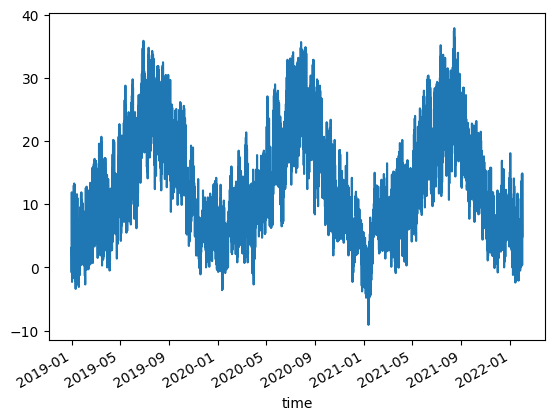

In [2]:
weather.set_index("time").loc[:, "temperature"].plot()

<Axes: xlabel='time'>

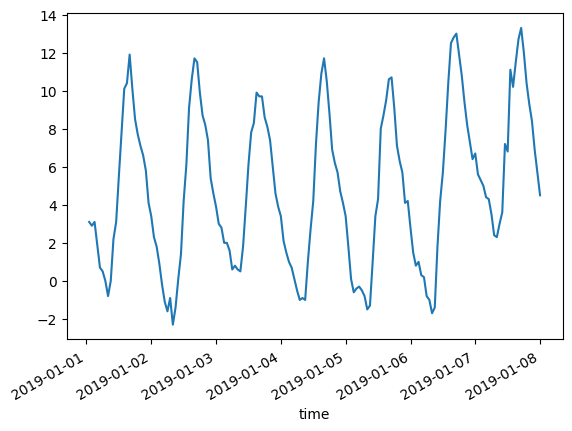

In [3]:
weather.set_index("time").loc[:"2019-01-07", "temperature"].plot()

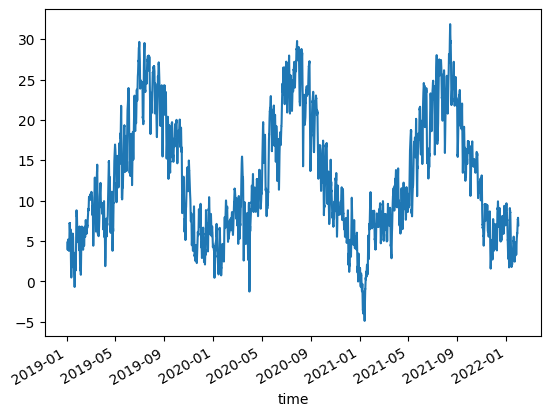

In [4]:
# 24h = daily moving average
weather.set_index("time").loc[:, "temperature"].rolling((24)).mean().plot();

<Axes: xlabel='time'>

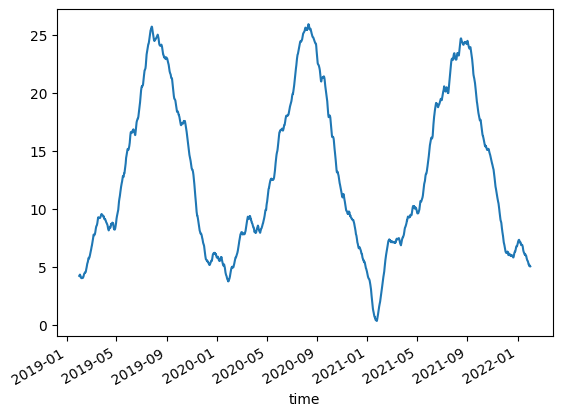

In [6]:
# (24 * 30) = 30-day moving average
 
weather.set_index("time").loc[:, "temperature"].rolling((24 * 30)).mean().plot()

<Axes: xlabel='time'>

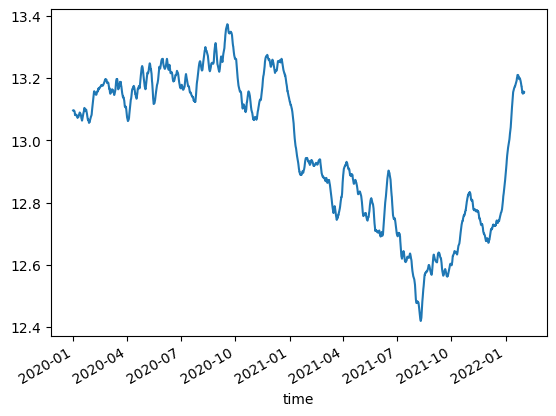

In [7]:
# (24 * 365) = yearly moving average
 
 
weather.set_index("time").loc[:, "temperature"].rolling((24 * 365)).mean().plot()

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
 
taco_stands = pd.read_csv(r"C:\Users\linke\Desktop\Python\DATA\taco_stands.csv", parse_dates=["Date"])
 
taco_stands.tail(30)

C:\Users\linke\AppData\Local\Temp\ipykernel_18728\378386878.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  taco_stands = pd.read_csv(r"C:\Users\linke\Desktop\Python\DATA\taco_stands.csv", parse_dates=["Date"])


,Date,Taco Stands in LA
210,2027-07-01,232
211,2027-08-01,240
212,2027-09-01,233
213,2027-10-01,231
214,2027-11-01,230
215,2027-12-01,228
216,2028-01-01,228
217,2028-02-01,231
218,2028-03-01,231
219,2028-04-01,235


<Axes: xlabel='Date'>

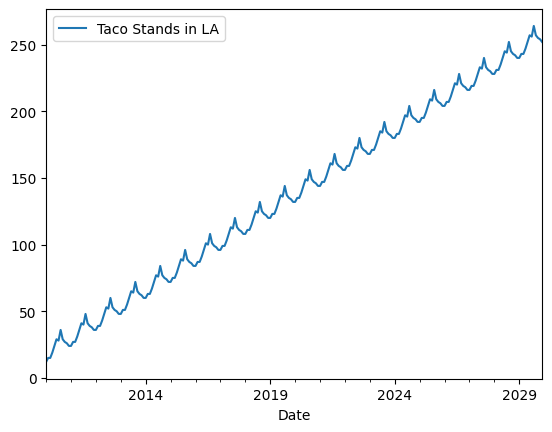

In [9]:
taco_stands.set_index("Date").plot()

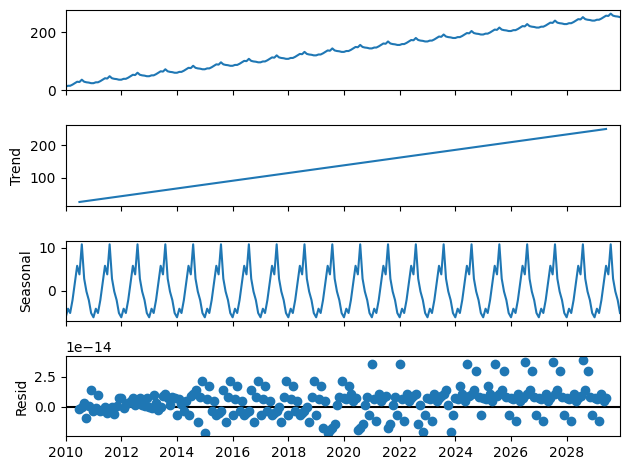

In [10]:
# full year (or full hour)
seasonal_decompose(taco_stands.set_index("Date")).plot();

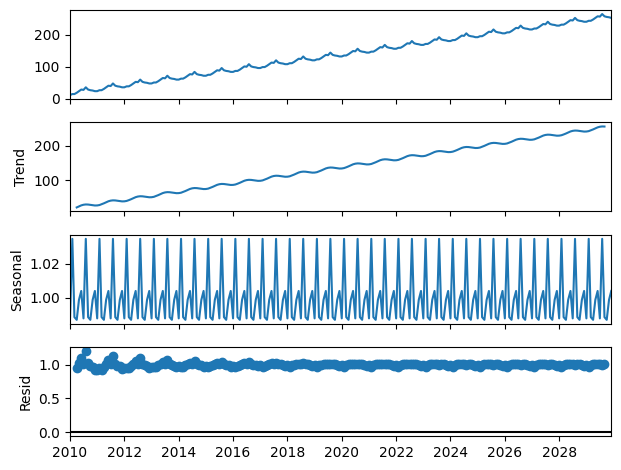

In [11]:

# 6 months
seasonal_decompose(taco_stands.set_index("Date"), model="multiplicative", period=6).plot();

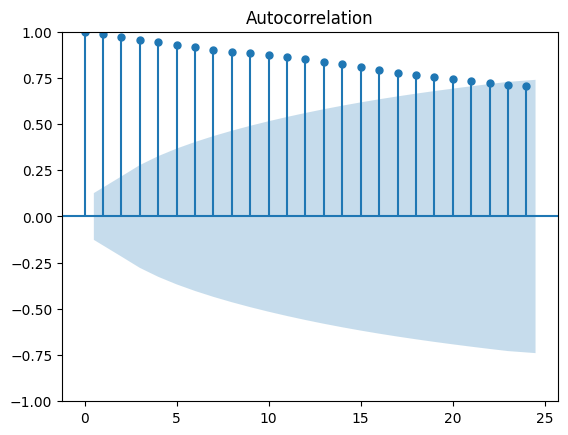

In [12]:
from statsmodels.graphics.tsaplots import plot_acf
 
 
#data still has trend in it
plot_acf(taco_stands.set_index("Date"));

In [13]:
# diff() allows to remove trend from data
taco_stands.set_index("Date")["Taco Stands in LA"].diff()

Date
2010-01-01    NaN
2010-02-01    3.0
2010-03-01    0.0
2010-04-01    4.0
2010-05-01    5.0
             ... 
2029-08-01    8.0
2029-09-01   -7.0
2029-10-01   -2.0
2029-11-01   -1.0
2029-12-01   -2.0
Name: Taco Stands in LA, Length: 240, dtype: float64

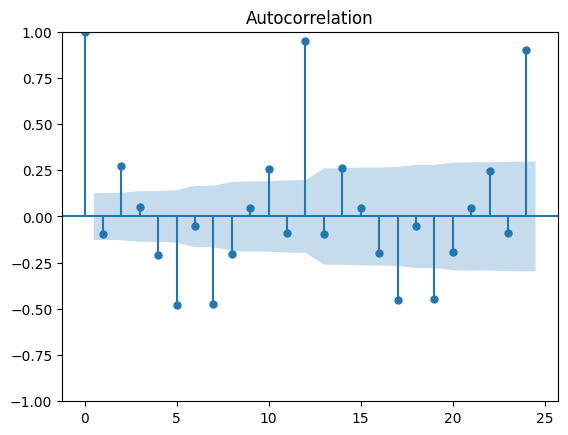

In [14]:
from statsmodels.graphics.tsaplots import plot_acf
 
# Need to difference our series to remove trend, slicing off missing value to plot
 
plot_acf(taco_stands["Taco Stands in LA"].diff()[1:]);

In [16]:
monthly_weather =(
    weather
    .set_index("time")
    .resample("ME")
    .agg({"temperature": "mean"})
    .reset_index()
)

In [17]:
# Create Trend and Seasonal Variables
 
monthly_weather = monthly_weather.assign(
    trend=range(len(monthly_weather)),
    month=monthly_weather["time"].dt.month
)

In [18]:
monthly_weather.head()

,time,temperature,trend,month
0,2019-01-31,4.267473,0,1
1,2019-02-28,6.645982,1,2
2,2019-03-31,9.244489,2,3
3,2019-04-30,9.032222,3,4
4,2019-05-31,15.345968,4,5


In [19]:
# Get Seasonal Dummies
 
month_dummies = pd.get_dummies(
    monthly_weather["month"].astype(int),
    prefix="m",
    drop_first=True,
    dtype=int
)
 
monthly_weather = (
    monthly_weather
    .drop(columns=["month"])
    .join(month_dummies)
)
 
# Saugiklis: jei liko True/False stulpelių, paversti į 0/1
bool_cols = monthly_weather.select_dtypes(include="bool").columns
monthly_weather[bool_cols] = monthly_weather[bool_cols].astype(int)
 
monthly_weather.tail()

,time,temperature,trend,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
32,2021-09-30,17.679583,32,0,0,0,0,0,0,0,1,0,0,0
33,2021-10-31,13.863306,33,0,0,0,0,0,0,0,0,1,0,0
34,2021-11-30,6.686667,34,0,0,0,0,0,0,0,0,0,1,0
35,2021-12-31,6.859140,35,0,0,0,0,0,0,0,0,0,0,1
36,2022-01-31,5.027500,36,0,0,0,0,0,0,0,0,0,0,0


In [20]:
# Split Data Based on Time
 
weather_train = monthly_weather.set_index("time").loc[:"2021-09"] #predict final 4 months in dataset
weather_test = monthly_weather.set_index("time").loc["2021-10-31":]
 
weather_test

,temperature,trend,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
time,,,,,,,,,,,,,
2021-10-31,13.863306,33,0,0,0,0,0,0,0,0,1,0,0
2021-11-30,6.686667,34,0,0,0,0,0,0,0,0,0,1,0
2021-12-31,6.859140,35,0,0,0,0,0,0,0,0,0,0,1
2022-01-31,5.027500,36,0,0,0,0,0,0,0,0,0,0,0


In [23]:
# Make Predictions
import statsmodels.api as sm

y_test = weather_test["temperature"]
X_test = sm.add_constant(weather_test.iloc[:,1:]) #.drop("trend", axis=1)
 
prediction = model.predict(X_test)
prediction

NameError: name 'model' is not defined

In [24]:
# Predictions vs. Actual DataFrame
 
pred_df = pd.DataFrame({"actual": y_test, "predicted": prediction})
 
pred_df

NameError: name 'prediction' is not defined

In [25]:
# Performance Metrics
 
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae
 
print(mape(pred_df["actual"], pred_df["predicted"]))
print(mae(pred_df["actual"], pred_df["predicted"]))

NameError: name 'pred_df' is not defined

In [26]:
pred_df.plot()

NameError: name 'pred_df' is not defined